# f6_m04c_sostenibilidad.ipynb

## Qué hace
Mide la huella de carbono y el consumo de memoria de los modelos principales.
Usa codecarbon para estimar emisiones de CO2 durante la inferencia.
Compara CatBoost, RF y Stacking en términos de sostenibilidad computacional.

## Requisitos
- `data/05_modelado/X_test_prep.parquet`
- `data/05_modelado/models/CatBoost__balanced.pkl`
- `data/05_modelado/models/RandomForest__balanced.pkl`
- `data/05_modelado/models/Stacking__balanced.pkl`
- Paquete: codecarbon

## Genera
- `results/fase6/sostenibilidad_metricas.parquet`
- `results/fase6/sostenibilidad_comparativa.png`
- `docs/html/fase6/m04c_sostenibilidad.html`

## Flujo
Cargar datos → medir tiempo + memoria + CO2 por modelo →
comparativa → HTML

## Siguiente
`f6_m05_informe_final.ipynb` — síntesis de todos los resultados

In [1]:
# 1. CONFIGURACIÓN DE RUTAS
import sys
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

def _encontrar_root(start: Path) -> Path:
    for parent in [start] + list(start.parents):
        if (parent / 'src').is_dir():
            return parent
    raise FileNotFoundError('No se encontró src/ subiendo desde ' + str(start))

ROOT = _encontrar_root(Path.cwd())
sys.path.insert(0, str(ROOT))

DIR_MODELS  = ROOT / 'data' / '05_modelado' / 'models'
DIR_DATA    = ROOT / 'data' / '05_modelado'
DIR_RESULTS = ROOT / 'results' / 'fase6'
DIR_RESULTS.mkdir(parents=True, exist_ok=True)

print(f'ROOT:        {ROOT}')
print(f'DIR_RESULTS: {DIR_RESULTS}')

ROOT:        C:\Users\mjmor\OneDrive - Universitat Jaume I\2.- AU_UJI
DIR_RESULTS: C:\Users\mjmor\OneDrive - Universitat Jaume I\2.- AU_UJI\results\fase6


In [2]:
# 2. IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import time
import tracemalloc
from codecarbon import EmissionsTracker
from src.html.render import render_pagina_desde_fichero

plt.rcParams['figure.dpi'] = 120

print('Imports OK.')

Imports OK.


In [3]:
# 3. CARGAR DATOS Y MODELOS
X_test_prep = pd.read_parquet(DIR_DATA / 'X_test_prep.parquet')

modelos = {
    'CatBoost':    joblib.load(DIR_MODELS / 'CatBoost__balanced.pkl'),
    'RandomForest': joblib.load(DIR_MODELS / 'RandomForest__balanced.pkl'),
    'Stacking':    joblib.load(DIR_MODELS / 'Stacking__balanced.pkl'),
}

print(f'X_test_prep: {X_test_prep.shape}')
print(f'Modelos cargados: {list(modelos.keys())}')

X_test_prep: (6725, 19)
Modelos cargados: ['CatBoost', 'RandomForest', 'Stacking']


In [4]:
# 4. MEDIR TIEMPO, MEMORIA Y CO2 POR MODELO
# Para cada modelo medimos:
#   - Tiempo de inferencia sobre X_test_prep (ms por observación)
#   - Memoria pico durante la inferencia (MB)
#   - Emisiones CO2 estimadas (gramos) usando codecarbon
# Repetimos 3 veces y tomamos la media para reducir variabilidad.

N_REPS = 3
resultados = []

for nombre, modelo in modelos.items():
    print(f'Midiendo {nombre}...')
    tiempos = []
    memorias = []

    for rep in range(N_REPS):
        # Tiempo
        t0 = time.perf_counter()
        _ = modelo.predict_proba(X_test_prep)
        t1 = time.perf_counter()
        tiempos.append(t1 - t0)

        # Memoria
        tracemalloc.start()
        _ = modelo.predict_proba(X_test_prep)
        _, pico = tracemalloc.get_traced_memory()
        tracemalloc.stop()
        memorias.append(pico / 1024 / 1024)  # bytes → MB

    # CO2 — una sola medición (codecarbon necesita unos segundos mínimos)
    tracker = EmissionsTracker(output_dir=str(DIR_RESULTS), log_level='error',
                               save_to_file=False)
    tracker.start()
    for _ in range(10):  # repetir para tener señal medible
        _ = modelo.predict_proba(X_test_prep)
    emisiones = tracker.stop()  # kg CO2
    emisiones_g = (emisiones or 0) * 1000 / 10  # gramos por inferencia

    tiempo_medio  = np.mean(tiempos)
    memoria_media = np.mean(memorias)
    ms_por_obs    = tiempo_medio / len(X_test_prep) * 1000

    resultados.append({
        'modelo':         nombre,
        'tiempo_s':       round(tiempo_medio, 3),
        'ms_por_obs':     round(ms_por_obs, 4),
        'memoria_mb':     round(memoria_media, 2),
        'co2_g':          round(emisiones_g, 6),
    })
    print(f'  Tiempo: {tiempo_medio:.3f}s | {ms_por_obs:.4f}ms/obs | '
          f'Memoria: {memoria_media:.1f}MB | CO2: {emisiones_g:.6f}g')

df_sos = pd.DataFrame(resultados)
df_sos.to_parquet(DIR_RESULTS / 'sostenibilidad_metricas.parquet')
print('\nMétricas guardadas.')
print(df_sos.to_string(index=False))

[codecarbon WARNING @ 00:04:32] Multiple instances of codecarbon are allowed to run at the same time.


Midiendo CatBoost...


  Tiempo: 0.004s | 0.0006ms/obs | Memoria: 0.2MB | CO2: 0.000159g
Midiendo RandomForest...


  Tiempo: 0.294s | 0.0438ms/obs | Memoria: 3.2MB | CO2: 0.000494g
Midiendo Stacking...


  Tiempo: 0.306s | 0.0454ms/obs | Memoria: 3.4MB | CO2: 0.000494g

Métricas guardadas.
      modelo  tiempo_s  ms_por_obs  memoria_mb    co2_g
    CatBoost     0.004      0.0006        0.21 0.000159
RandomForest     0.294      0.0438        3.25 0.000494
    Stacking     0.306      0.0454        3.37 0.000494


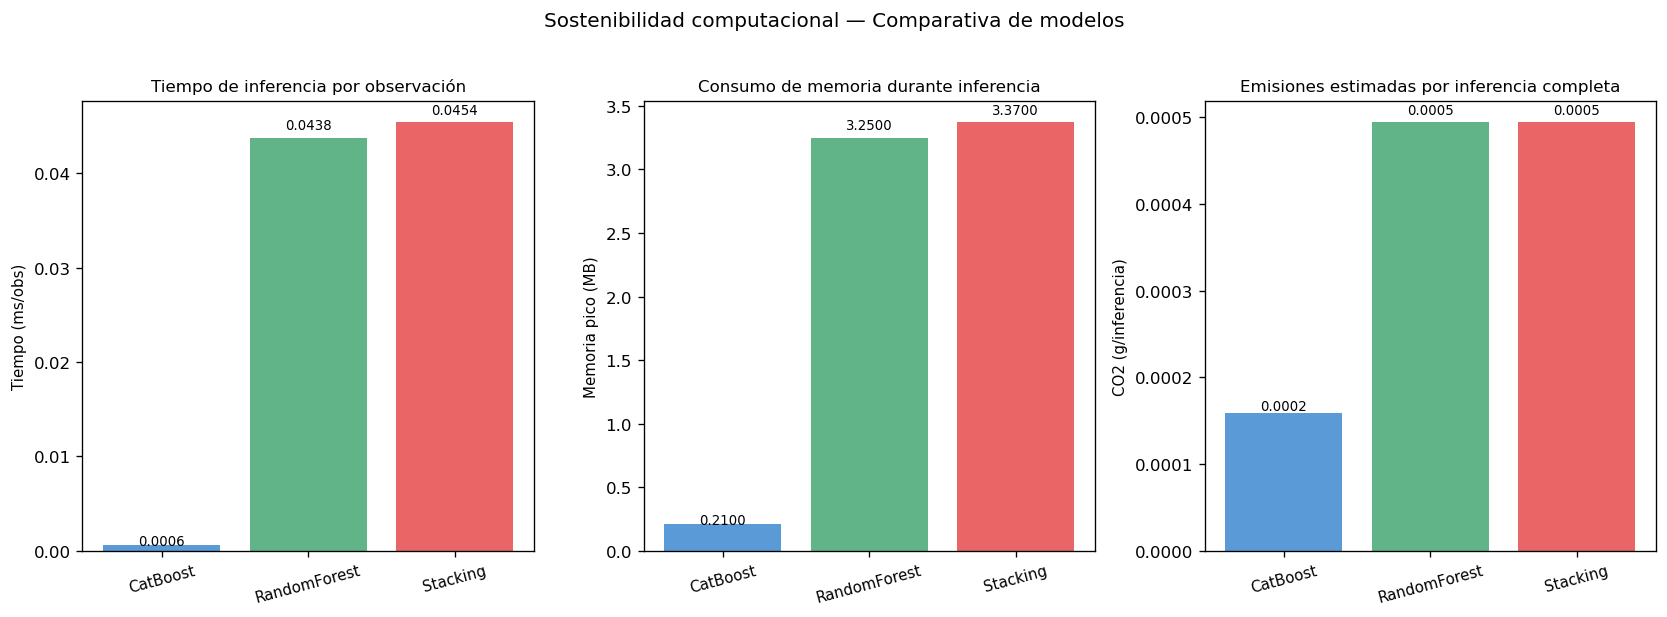

Gráfico guardado.


In [5]:
# 5. GRÁFICO COMPARATIVO
# 3 subplots: tiempo de inferencia, memoria pico, emisiones CO2.

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
colores   = ['#3182ce', '#38a169', '#e53e3e']
metricas  = [
    ('ms_por_obs', 'Tiempo (ms/obs)', 'Tiempo de inferencia por observación'),
    ('memoria_mb', 'Memoria pico (MB)', 'Consumo de memoria durante inferencia'),
    ('co2_g',      'CO2 (g/inferencia)', 'Emisiones estimadas por inferencia completa'),
]

for ax, (col, ylabel, titulo) in zip(axes, metricas):
    bars = ax.bar(df_sos['modelo'], df_sos[col], color=colores, alpha=0.8)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(titulo, fontsize=10)
    ax.tick_params(axis='x', rotation=15, labelsize=9)
    # Anotar valores encima de cada barra
    for bar, val in zip(bars, df_sos[col]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
                f'{val:.4f}', ha='center', fontsize=8)

plt.suptitle('Sostenibilidad computacional — Comparativa de modelos', fontsize=12, y=1.02)
plt.tight_layout()
ruta_sos = DIR_RESULTS / 'sostenibilidad_comparativa.png'
plt.savefig(ruta_sos, dpi=120, bbox_inches='tight')
plt.show()
print('Gráfico guardado.')

In [6]:
# 6. GENERAR HTML
import base64

def img_b64(ruta: Path) -> str:
    if not ruta.exists():
        return ''
    with open(ruta, 'rb') as f:
        return base64.b64encode(f.read()).decode()

def bloque_imagen(b64: str, titulo: str, caption: str) -> str:
    if not b64:
        return f'<p style="color:#e53e3e">Imagen no disponible: {titulo}</p>'
    return (
        '<div style="margin:24px 0">'
        f'<h3 style="color:#2d3748; font-size:15px">{titulo}</h3>'
        f'<img src="data:image/png;base64,{b64}" style="max-width:100%; border-radius:6px; box-shadow:0 2px 8px rgba(0,0,0,.1)">'
        f'<p style="color:#718096; font-size:12px; margin-top:6px">{caption}</p>'
        '</div>'
    )

filas_tabla = ''
for _, row in df_sos.iterrows():
    filas_tabla += (
        '<tr>'
        f'<td style="padding:8px 12px; font-weight:600">{row["modelo"]}</td>'
        f'<td style="padding:8px 12px; text-align:center">{row["tiempo_s"]:.3f}s</td>'
        f'<td style="padding:8px 12px; text-align:center">{row["ms_por_obs"]:.4f}</td>'
        f'<td style="padding:8px 12px; text-align:center">{row["memoria_mb"]:.1f}</td>'
        f'<td style="padding:8px 12px; text-align:center">{row["co2_g"]:.6f}</td>'
        '</tr>'
    )

contenido = (
    '<h2 style="color:#2d3748">Sostenibilidad Computacional</h2>'
    '<p style="color:#4a5568; font-size:14px; max-width:800px">'
    'Análisis del coste computacional y la huella de carbono de los tres modelos '
    'principales en inferencia sobre el conjunto de test completo (6.725 observaciones). '
    'Las emisiones de CO2 se estiman con codecarbon a partir del consumo energético '
    'y la intensidad de carbono de la red eléctrica local.'
    '</p>'
    '<table style="width:100%; border-collapse:collapse; font-size:13px; margin:20px 0">'
    '<thead><tr style="background:#edf2f7">'
    '<th style="padding:8px 12px; text-align:left">Modelo</th>'
    '<th style="padding:8px 12px; text-align:center">Tiempo total</th>'
    '<th style="padding:8px 12px; text-align:center">ms / observación</th>'
    '<th style="padding:8px 12px; text-align:center">Memoria pico (MB)</th>'
    '<th style="padding:8px 12px; text-align:center">CO2 (g)</th>'
    '</tr></thead>'
    f'<tbody>{filas_tabla}</tbody></table>'
    + bloque_imagen(img_b64(ruta_sos),
        'Comparativa de sostenibilidad — CatBoost vs RF vs Stacking',
        'Tiempo de inferencia por observación, consumo de memoria pico '
        'y emisiones estimadas de CO2 por inferencia completa sobre el conjunto de test.')
    + '<div style="margin-top:24px; padding:16px; background:#ebf8ff; '
    + 'border-left:4px solid #3182ce; border-radius:6px; font-size:13px; color:#2c5282">'
    + '<strong>Contexto:</strong> En un sistema de alerta temprana universitario, '
    + 'la inferencia se ejecutaría una vez por curso académico sobre todos los alumnos activos. '
    + 'El coste computacional es, por tanto, marginal en términos absolutos. '
    + 'La comparativa es relevante si el sistema escala a múltiples universidades o '
    + 'si se requiere inferencia en tiempo real (consulta alumno a alumno).'
    + '</div>'
)

html_completo = render_pagina_desde_fichero('f6_m04c_sostenibilidad.ipynb', contenido)
ruta_html = ROOT / 'docs' / 'html' / 'fase6' / 'm04c_sostenibilidad.html'
ruta_html.parent.mkdir(parents=True, exist_ok=True)
ruta_html.write_text(html_completo, encoding='utf-8')
print(f'HTML generado: {ruta_html}')

HTML generado: C:\Users\mjmor\OneDrive - Universitat Jaume I\2.- AU_UJI\docs\html\fase6\m04c_sostenibilidad.html
